In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv("eu_loneliness_survey_eu4_labels.csv")

In [73]:
cols_to_use = ["country","gender", "age","age_class","loneliness_direct", "loneliness_intensity", "health_condition", "relationship",'adults_n']

In [74]:
df1 = df[cols_to_use].copy()

In [75]:
mapping = {
    "All of the time": 1,
    "Most of the time": 1,
    "Some of the time": 1,
    "A little of the time": 1,
    "None of the time": 0,
    "Don't know": 0,
    "Prefer not to say": 0
}


df1["lonely_binary"] = df1["loneliness_direct"].map(mapping)

In [76]:
df1["country"].unique()

array(['France', 'Poland', 'Sweden', 'Italy'], dtype=object)

In [77]:
older = df1[df1["age"] >= 60]

summary = (
    older.groupby("country")["lonely_binary"]
    .mean()
    .reset_index()
)

summary["percent_lonely"] = summary["lonely_binary"]*100
summary = summary.sort_values("percent_lonely")

singapore_row = pd.DataFrame({
    "country": ["Singapore"],
    "lonely_binary": [127/528],
    "percent_lonely": [127/528*100]
})

summary = pd.concat([summary, singapore_row], ignore_index=True)

summary = summary.sort_values("percent_lonely")

print(summary)


     country  lonely_binary  percent_lonely
4  Singapore       0.240530       24.053030
0     Sweden       0.395161       39.516129
1      Italy       0.474255       47.425474
2     Poland       0.479730       47.972973
3     France       0.482850       48.284960


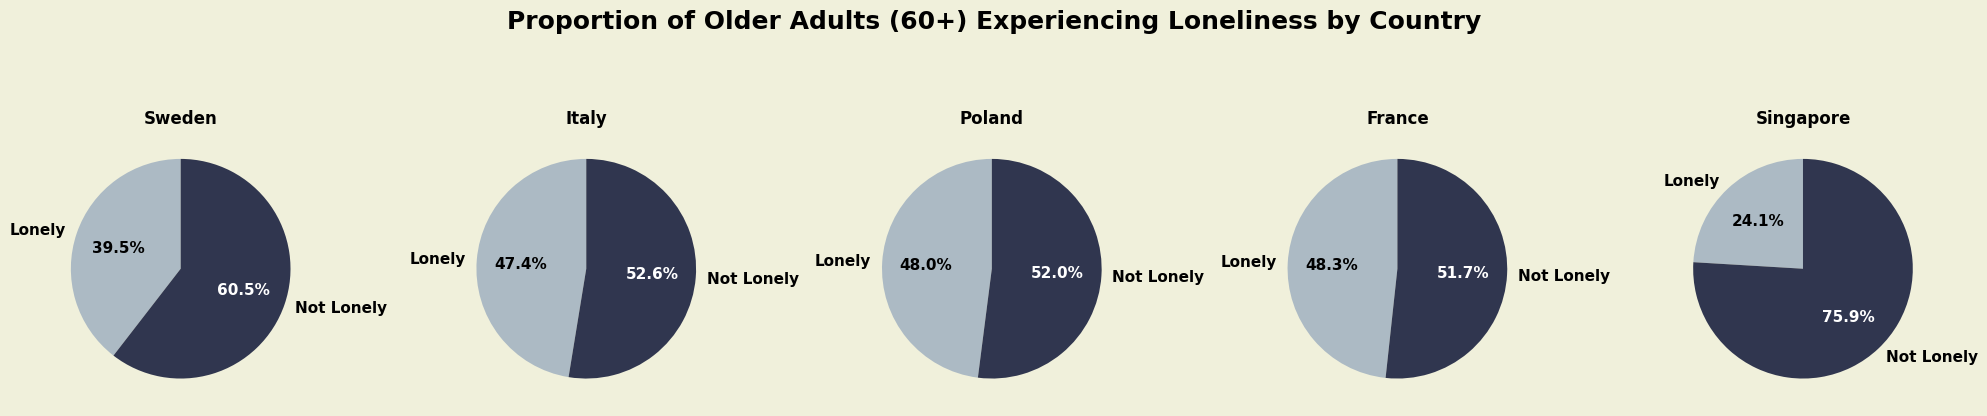

In [78]:
summary['percent_not_lonely'] = 100 - summary['percent_lonely']


fig, axes = plt.subplots(1, len(summary), figsize=(20, 5))

bg_color = '#F0F0DB'
fig.patch.set_facecolor(bg_color)
for ax in axes:
    ax.set_facecolor(bg_color)

for i, row in summary.iterrows():
    wedges, texts, autotexts = axes[i].pie(
        [row['percent_lonely'], row['percent_not_lonely']],
        labels=['Lonely', 'Not Lonely'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#ACBAC4', "#30364F"],
        textprops={'fontsize': 11, 'fontweight': 'bold'}
)   
    x = 0
    for autotext in autotexts:
        if x % 2 != 0:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
        x+=1

    axes[i].set_title(row['country'], fontweight = "bold")

fig.suptitle('Proportion of Older Adults (60+) Experiencing Loneliness by Country', fontsize=18, weight = "bold")
plt.tight_layout()
plt.show()

# Plot 2

In [79]:
older1 = older.copy()

In [80]:
def map_relatiosnhip(status):
    if status == 'Married or cohabitating':
        return 'Married'
    elif status in ['Single', 'Separated or divorced', 'Widowed', 'In a relationship']:
        return 'Not married'
    else:
        return None

def recode_adults(n):
    if n <= 2:
        return "2 or less"
    else:
        return "3 or more"


In [81]:

older1['married_status'] = older1['relationship'].apply(map_relatiosnhip)

older1 = older1.dropna(subset=['married_status'])

older1['adults_group'] = older1['adults_n'].apply(recode_adults)

older1 = older1[older1['gender'].isin(['Male', 'Female'])]

older1 = older1[older1['health_condition'].isin(['Yes', 'No'])]

older1['health_condition'] = older1['health_condition'].map({'Yes': 'Poor Condition', 'No': 'Good Condition'})


In [82]:
older1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1156 entries, 10 to 4028
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               1156 non-null   object 
 1   gender                1156 non-null   object 
 2   age                   1156 non-null   int64  
 3   age_class             1156 non-null   object 
 4   loneliness_direct     1156 non-null   object 
 5   loneliness_intensity  503 non-null    object 
 6   health_condition      1156 non-null   object 
 7   relationship          1156 non-null   object 
 8   adults_n              1156 non-null   int64  
 9   lonely_binary         1129 non-null   float64
 10  married_status        1156 non-null   object 
 11  adults_group          1156 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 117.4+ KB


In [83]:
cols = ['country', 'gender', 'health_condition', 'married_status', 'adults_group', 'lonely_binary']
df_plot2 = older1[cols].copy()


In [84]:
df_plot2 = df_plot2.dropna(subset=['lonely_binary'])


In [85]:
data_sg = {
    'Factor': [
        'gender', 'gender',
        'health_condition', 'health_condition',
        'married_status', 'married_status',
        'adults_group', 'adults_group'
    ],
    'Level': [
        'Male', 'Female',
        'Poor Condition', 'Good Condition',
        'Married', 'Not married',
        '2 or less', '3 or more'
    ],
    'N_not_lonely': [
        166, 235,
        93, 308,
        233, 168,
        232, 169
    ],
    'N_lonely': [
        54, 73,
        41, 86,
        55, 72,
        61, 66
    ]
}

df_sg = pd.DataFrame(data_sg)
df_sg['N_total'] = df_sg['N_not_lonely'] + df_sg['N_lonely']
df_sg['%_lonely'] = df_sg['N_lonely'] / df_sg['N_total'] * 100
df_sg['Region'] = 'SG'
df_sg = df_sg[['Factor', 'Level', 'Region', 'N_total', 'N_not_lonely', 'N_lonely', '%_lonely']]

df_sg


,Factor,Level,Region,N_total,N_not_lonely,N_lonely,%_lonely
0,gender,Male,SG,220,166,54,24.545455
1,gender,Female,SG,308,235,73,23.701299
2,health_condition,Poor Condition,SG,134,93,41,30.597015
3,health_condition,Good Condition,SG,394,308,86,21.827411
4,married_status,Married,SG,288,233,55,19.097222
5,married_status,Not married,SG,240,168,72,30.000000
6,adults_group,2 or less,SG,293,232,61,20.819113
7,adults_group,3 or more,SG,235,169,66,28.085106


In [86]:
def summarize_eu(df, factor):
    summary = df.groupby(factor)['lonely_binary'].agg(
        N_lonely='sum',
        N_total='count'
    ).reset_index()
    summary['N_not_lonely'] = summary['N_total'] - summary['N_lonely']
    summary['%_lonely'] = summary['N_lonely'] / summary['N_total']*100
    summary['Factor'] = factor
    summary['Region'] = 'EU'
    summary = summary.rename(columns={factor: 'Level'})
    return summary[['Factor', 'Level', 'Region', 'N_total', 'N_not_lonely', 'N_lonely', '%_lonely']]

factors = ['gender', 'health_condition', 'married_status', 'adults_group']
summary_list = [summarize_eu(older1, f) for f in factors]

df_eu = pd.concat(summary_list, ignore_index=True)

df_eu


,Factor,Level,Region,N_total,N_not_lonely,N_lonely,%_lonely
0,gender,Female,EU,553,287.0,266.0,48.101266
1,gender,Male,EU,576,339.0,237.0,41.145833
2,health_condition,Good Condition,EU,722,425.0,297.0,41.135734
3,health_condition,Poor Condition,EU,407,201.0,206.0,50.614251
4,married_status,Married,EU,743,461.0,282.0,37.954240
5,married_status,Not married,EU,386,165.0,221.0,57.253886
6,adults_group,2 or less,EU,981,550.0,431.0,43.934760
7,adults_group,3 or more,EU,148,76.0,72.0,48.648649


In [87]:
df_plot2 = pd.concat([df_eu, df_sg], ignore_index=True)
df_plot2


,Factor,Level,Region,N_total,N_not_lonely,N_lonely,%_lonely
0,gender,Female,EU,553,287.0,266.0,48.101266
1,gender,Male,EU,576,339.0,237.0,41.145833
2,health_condition,Good Condition,EU,722,425.0,297.0,41.135734
3,health_condition,Poor Condition,EU,407,201.0,206.0,50.614251
4,married_status,Married,EU,743,461.0,282.0,37.954240
5,married_status,Not married,EU,386,165.0,221.0,57.253886
6,adults_group,2 or less,EU,981,550.0,431.0,43.934760
7,adults_group,3 or more,EU,148,76.0,72.0,48.648649
8,gender,Male,SG,220,166.0,54.0,24.545455
9,gender,Female,SG,308,235.0,73.0,23.701299


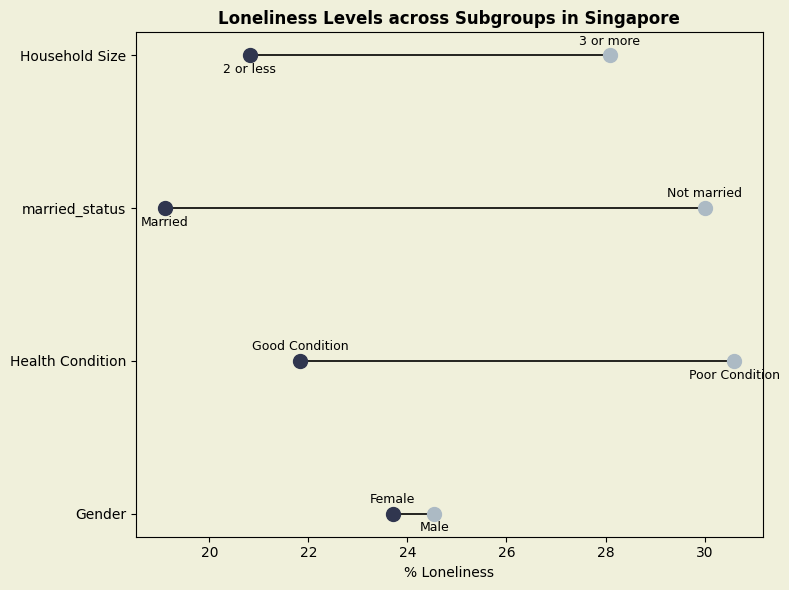

In [88]:
import matplotlib.pyplot as plt

factors = df_plot2['Factor'].unique()

min_color = '#30364F'
highlight_color = '#ACBAC4'

plt.figure(figsize=(8, 6))
plt.gca().set_facecolor('#F0F0DB')
plt.gcf().patch.set_facecolor('#F0F0DB')

y_positions = range(len(factors))

for y, factor in zip(y_positions, factors):
    df_factor = df_plot2[(df_plot2['Factor']==factor) & (df_plot2['Region']=='SG')]
    levels = df_factor['Level'].values
    values = df_factor['%_lonely'].values

    more_lonely_index = 0 if values[0] > values[1] else 1
    colors = [min_color, min_color]
    colors[more_lonely_index] = highlight_color

    plt.plot(values, [y, y], marker='o', linestyle='-', color='black', linewidth=1.2)

    for j, (val, color, lvl) in enumerate(zip(values, colors, levels)):
        plt.scatter(val, y, color=color, s=100, zorder=5)
        offset = -0.05 if j == 0 else 0.05
        va = 'top' if j == 0 else 'bottom'
        plt.text(val, y + offset, lvl, ha='center', va=va, fontsize=9)

factor_labels = {
    'gender': 'Gender',
    'relationship': 'Marital Status',
    'health_condition': 'Health Condition',
    'adults_group': 'Household Size'
}


plt.yticks(y_positions, [factor_labels.get(f, f) for f in factors])
plt.xlabel("% Loneliness")
plt.title("Loneliness Levels across Subgroups in Singapore", weight = "bold")
plt.tight_layout()
plt.show()


# Plot 3

In [89]:
intervention_cols = [f"interventions_done__{i}" for i in range(1, 13)]

cols_to_use += intervention_cols

print(cols_to_use)

['country', 'gender', 'age', 'age_class', 'loneliness_direct', 'loneliness_intensity', 'health_condition', 'relationship', 'adults_n', 'interventions_done__1', 'interventions_done__2', 'interventions_done__3', 'interventions_done__4', 'interventions_done__5', 'interventions_done__6', 'interventions_done__7', 'interventions_done__8', 'interventions_done__9', 'interventions_done__10', 'interventions_done__11', 'interventions_done__12']


In [90]:
df1 = df[cols_to_use].copy()

mapping = {
    "All of the time": 1,
    "Most of the time": 1,
    "Some of the time": 1,
    "A little of the time": 1,
    "None of the time": 0,
    "Don't know": 0,
    "Prefer not to say": 0
}

df1["lonely_binary"] = df1["loneliness_direct"].map(mapping)

In [91]:
older = df1[df1["age"] >= 60]

older = older[older['lonely_binary']==1]

older['married_status'] = older['relationship'].apply(map_relatiosnhip)

older = older.dropna(subset=['married_status'])

older['adults_group'] = older['adults_n'].apply(recode_adults)

older = older[older['gender'].isin(['Male', 'Female'])]

older = older[older['health_condition'].isin(['Yes', 'No'])]

older['health_condition'] = older['health_condition'].map({'Yes': 'Poor Condition', 'No': 'Good Condition'})


In [92]:
dfplot3_1 = older[older['health_condition'] == "Poor Condition"]


In [93]:
dfplot3_1 = dfplot3_1[dfplot3_1['married_status'] == "Not married"]
dfplot3_1

,country,gender,age,age_class,loneliness_direct,loneliness_intensity,health_condition,relationship,adults_n,interventions_done__1,...,interventions_done__6,interventions_done__7,interventions_done__8,interventions_done__9,interventions_done__10,interventions_done__11,interventions_done__12,lonely_binary,married_status,adults_group
211,Italy,Female,61,56-65,Some of the time,5,Poor Condition,Widowed,2,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,Volunteered,NaN,NaN,NaN,1.0,Not married,2 or less
212,Italy,Male,81,65+,Most of the time,7,Poor Condition,Widowed,2,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,Volunteered,Used more social media,NaN,NaN,1.0,Not married,2 or less
362,Italy,Male,74,65+,A little of the time,5,Poor Condition,Widowed,2,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Not married,2 or less
365,Italy,Female,64,56-65,Some of the time,10,Poor Condition,Separated or divorced,4,NaN,...,NaN,Contacted a church or religious organisation,NaN,NaN,NaN,Took time for myself,NaN,1.0,Not married,3 or more
407,Poland,Female,68,65+,Some of the time,7,Poor Condition,Widowed,1,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,NaN,NaN,Took time for myself,NaN,1.0,Not married,2 or less
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3804,Sweden,Female,72,65+,Some of the time,5,Poor Condition,Widowed,1,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Not married,2 or less
3893,Italy,Female,69,65+,Some of the time,7,Poor Condition,Widowed,1,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,NaN,Used more social media,NaN,NaN,1.0,Not married,2 or less
3936,Italy,Male,80,65+,Some of the time,6,Poor Condition,Separated or divorced,1,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,NaN,NaN,Took time for myself,NaN,1.0,Not married,2 or less
4017,Sweden,Male,78,65+,A little of the time,3,Poor Condition,Widowed,1,NaN,...,NaN,NaN,NaN,NaN,NaN,Took time for myself,NaN,1.0,Not married,2 or less


In [94]:
dfplot3_2 = older[older['health_condition'] == "Good Condition"]

In [95]:
dfplot3_2 = dfplot3_2[dfplot3_2['married_status'] == "Married"]
dfplot3_2

,country,gender,age,age_class,loneliness_direct,loneliness_intensity,health_condition,relationship,adults_n,interventions_done__1,...,interventions_done__6,interventions_done__7,interventions_done__8,interventions_done__9,interventions_done__10,interventions_done__11,interventions_done__12,lonely_binary,married_status,adults_group
31,Sweden,Female,62,56-65,A little of the time,2,Good Condition,Married or cohabitating,3,NaN,...,NaN,NaN,NaN,NaN,NaN,Took time for myself,NaN,1.0,Married,3 or more
56,Italy,Female,64,56-65,A little of the time,4,Good Condition,Married or cohabitating,2,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,NaN,NaN,Took time for myself,NaN,1.0,Married,2 or less
74,France,Male,72,65+,Some of the time,6,Good Condition,Married or cohabitating,2,NaN,...,NaN,NaN,"Joined a club or a group (e.g., a sport club, ...",Volunteered,NaN,Took time for myself,NaN,1.0,Married,2 or less
88,France,Male,66,65+,A little of the time,1,Good Condition,Married or cohabitating,2,"Seeing friends, family members, or other loved...",...,NaN,NaN,"Joined a club or a group (e.g., a sport club, ...",NaN,NaN,Took time for myself,NaN,1.0,Married,2 or less
96,Italy,Male,78,65+,Some of the time,4,Good Condition,Married or cohabitating,2,NaN,...,NaN,NaN,NaN,NaN,Used more social media,NaN,NaN,1.0,Married,2 or less
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3808,Italy,Male,67,65+,A little of the time,7,Good Condition,Married or cohabitating,4,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,Volunteered,Used more social media,NaN,NaN,1.0,Married,3 or more
3836,France,Male,61,56-65,A little of the time,3,Good Condition,Married or cohabitating,2,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,NaN,Used more social media,NaN,NaN,1.0,Married,2 or less
3891,Sweden,Male,61,56-65,A little of the time,5,Good Condition,Married or cohabitating,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Wanted to do something but did not know what t...,1.0,Married,2 or less
3975,Italy,Male,65,56-65,A little of the time,3,Good Condition,Married or cohabitating,3,"Seeing friends, family members, or other loved...",...,NaN,NaN,NaN,NaN,Used more social media,Took time for myself,NaN,1.0,Married,3 or more


In [96]:

df_long_1 = dfplot3_1.melt(id_vars="lonely_binary", 
                         value_vars=intervention_cols, 
                         var_name="Intervention_Col", 
                         value_name="Intervention_Name")

df_long_1 = df_long_1.dropna(subset=['Intervention_Name'])
df_long_1 = df_long_1[df_long_1['lonely_binary'] == 1]

df_counts_1= df_long_1['Intervention_Name'].value_counts().reset_index()
df_counts_1.columns = ['Intervention', 'Count']

df_counts_1 = df_counts_1.sort_values('Count', ascending=False)


In [97]:

df_long_2 = dfplot3_2.melt(id_vars="lonely_binary", 
                         value_vars=intervention_cols, 
                         var_name="Intervention_Col", 
                         value_name="Intervention_Name")

df_long_2 = df_long_2.dropna(subset=['Intervention_Name'])
df_long_2 = df_long_2[df_long_2['lonely_binary'] == 1]

df_counts_2 = df_long_2['Intervention_Name'].value_counts().reset_index()
df_counts_2.columns = ['Intervention', 'Count']

df_counts_2 = df_counts_2.sort_values('Count', ascending=False)


C:\Users\chrst\AppData\Local\Temp\ipykernel_18696\2894318382.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chrst\AppData\Local\Temp\ipykernel_18696\2894318382.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


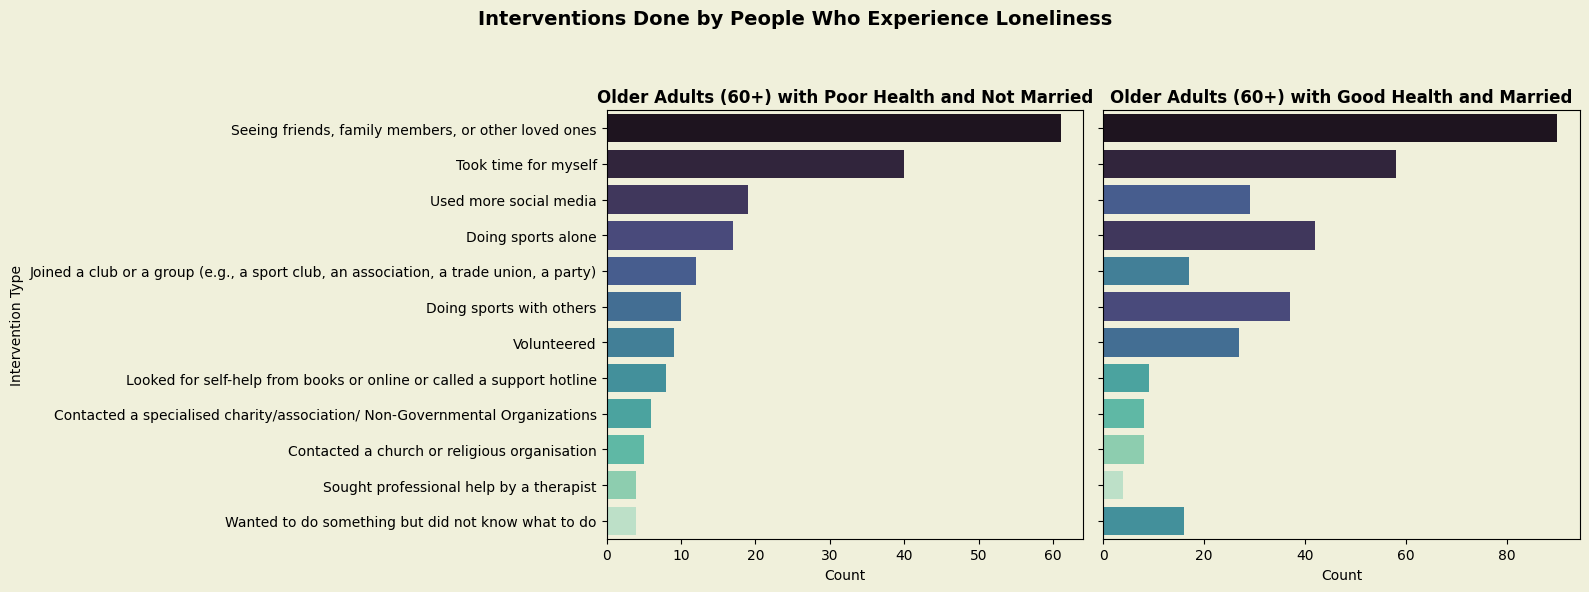

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

fig.patch.set_facecolor('#F0F0DB')
for ax in axes:
    ax.set_facecolor('#F0F0DB')

# Poor Con and not married
sns.barplot(
    data=df_counts_1,
    x='Count',
    y='Intervention',
    palette='mako',
    ax=axes[0]
)
axes[0].set_title("Older Adults (60+) with Poor Health and Not Married", fontweight='bold')
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Intervention Type")

# Good Con and not married
sns.barplot(
    data=df_counts_2,
    x='Count',
    y='Intervention',
    palette='mako',
    ax=axes[1]
)
axes[1].set_title("Older Adults (60+) with Good Health and Married", fontweight='bold')
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.suptitle(
    "Interventions Done by People Who Experience Loneliness",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()
